# 02 -- 整体销售分析

---

## 业务背景

作为分析师，老板问你的第一个问题往往是：**"最近生意怎么样？"**

这个问题背后其实是一组更具体的追问：
- GMV（总销售额）在涨还是跌？
- 涨跌是订单量变多了，还是客单价变了？
- 有没有季节性规律？大促期间表现如何？
- 支付方式、国家维度有没有值得关注的差异？

本节从宏观到微观，逐层拆解销售表现。

## 1. 环境与数据加载

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "WenQuanYi Micro Hei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

# 加载清洗后的数据
txn = pd.read_parquet('../output/transactions_wide.parquet')
txn_clean = pd.read_parquet('../output/transactions_clean.parquet')
customers = pd.read_parquet('../output/customers_clean.parquet')
products = pd.read_parquet('../output/products_clean.parquet')

# 只保留已完成订单用于 GMV 计算
completed = txn[txn['status'] == 'completed'].copy()
print(f"已完成订单: {len(completed):,} / 总订单: {len(txn):,} ({len(completed)/len(txn):.1%})")

C:\Users\Acer\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


已完成订单: 68,700 / 总订单: 120,000 (57.2%)


## 2. GMV 月度趋势

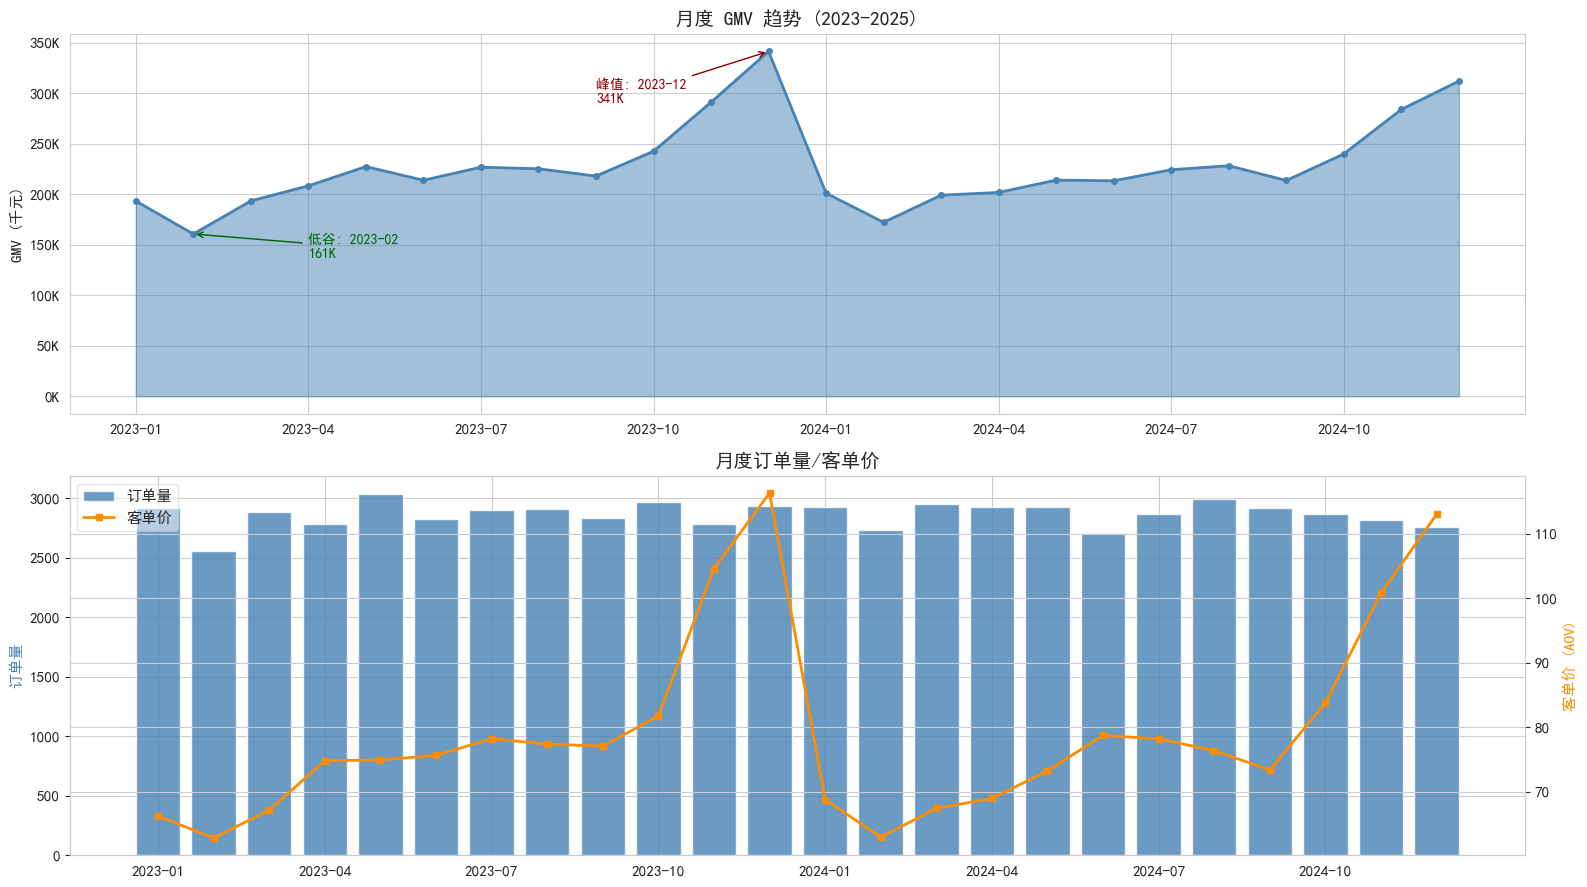

=== 整体销售数据 ===
总 GMV: 5,443,248
总订单数: 68,700
月均 GMV: 226,802
整体 AOV: 79.23
GMV 月环比平均增长率: 3.19%


In [3]:
# 月度 GMV 汇总
monthly_gmv = completed.groupby('year_month').agg(
    gmv=('total_amount', 'sum'),            #总交易额    
    orders=('transaction_id', 'nunique'),   #总订单(去重计算)
    customers=('customer_id', 'nunique'),   #消费人数(去重计算)
    aov=('total_amount', 'mean')            #客单价
).reset_index()                             #把行标签重新降级变回普通的数据列
#切换成字符型--避免x轴报错
monthly_gmv['year_month'] = monthly_gmv['year_month'].astype(str)       
monthly_gmv['gmv_k'] = monthly_gmv['gmv'] / 1000

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# GMV 趋势--使用面积折线图
axes[0].fill_between(range(len(monthly_gmv)), monthly_gmv['gmv_k'], alpha=0.5, color='steelblue')
axes[0].plot(monthly_gmv['gmv_k'], marker='o', color='steelblue', linewidth=2, markersize=4)
axes[0].set_title('月度 GMV 趋势 (2023-2025)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('GMV (千元)')
axes[0].set_xticks(range(0, len(monthly_gmv), 3))   #三个月显示一次刻度,方便阅读
axes[0].set_xticklabels(monthly_gmv['year_month'].iloc[::3])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}K'))

# 标注最高和最低月份
max_idx = monthly_gmv['gmv_k'].idxmax()
min_idx = monthly_gmv['gmv_k'].idxmin()
axes[0].annotate(f"峰值: {monthly_gmv['year_month'].iloc[max_idx]}\n{monthly_gmv['gmv_k'].iloc[max_idx]:,.0f}K",
                xy=(max_idx, monthly_gmv['gmv_k'].iloc[max_idx]),
                xytext=(max_idx-3, monthly_gmv['gmv_k'].iloc[max_idx]*0.85),
                arrowprops=dict(arrowstyle='->', color='darkred'),
                fontsize=10, color='darkred', fontweight='bold')
axes[0].annotate(f"低谷: {monthly_gmv['year_month'].iloc[min_idx]}\n{monthly_gmv['gmv_k'].iloc[min_idx]:,.0f}K",
                xy=(min_idx, monthly_gmv['gmv_k'].iloc[min_idx]),
                xytext=(min_idx+2, monthly_gmv['gmv_k'].iloc[min_idx]*0.85),
                arrowprops=dict(arrowstyle='->', color='darkgreen'),
                fontsize=10, color='darkgreen', fontweight='bold')

# 订单量 + 客单价趋势
ax2 = axes[1]
ax2.bar(range(len(monthly_gmv)), monthly_gmv['orders'], alpha=0.8, color='steelblue', label='订单量')
ax2.set_ylabel('订单量', color='steelblue')
ax2.set_xticks(range(0, len(monthly_gmv), 3))
ax2.set_xticklabels(monthly_gmv['year_month'].iloc[::3])

ax2_twin = ax2.twinx()
ax2_twin.plot(monthly_gmv['aov'], marker='s', color='darkorange', linewidth=2, markersize=4, label='客单价')
ax2_twin.set_ylabel('客单价 (AOV)', color='darkorange')
ax2_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left',framealpha=0.5)
ax2.set_title('月度订单量/客单价', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 关键数字
print(f"=== 整体销售数据 ===")
print(f"总 GMV: {monthly_gmv['gmv'].sum():,.0f}")
print(f"总订单数: {monthly_gmv['orders'].sum():,}")
print(f"月均 GMV: {monthly_gmv['gmv'].mean():,.0f}")
print(f"整体 AOV: {completed['total_amount'].mean():.2f}")
print(f"GMV 月环比平均增长率: {monthly_gmv['gmv'].pct_change().mean():.2%}")

**业务观察：**
- GMV 趋势反映了整体业务增长的健康度。如果呈现上升趋势，说明业务在扩张
- 订单量和客单价的**双轴图**帮助判断：GMV 的增长是"更多人买"还是"人均花更多"驱动的
- 如果是客单价驱动增长但订单量持平，可能需要关注用户增长是否碰到天花板


## 3. 时间维度分析

电商有明显的时间波动。我们分别从**月**和**周**两个维度来看。

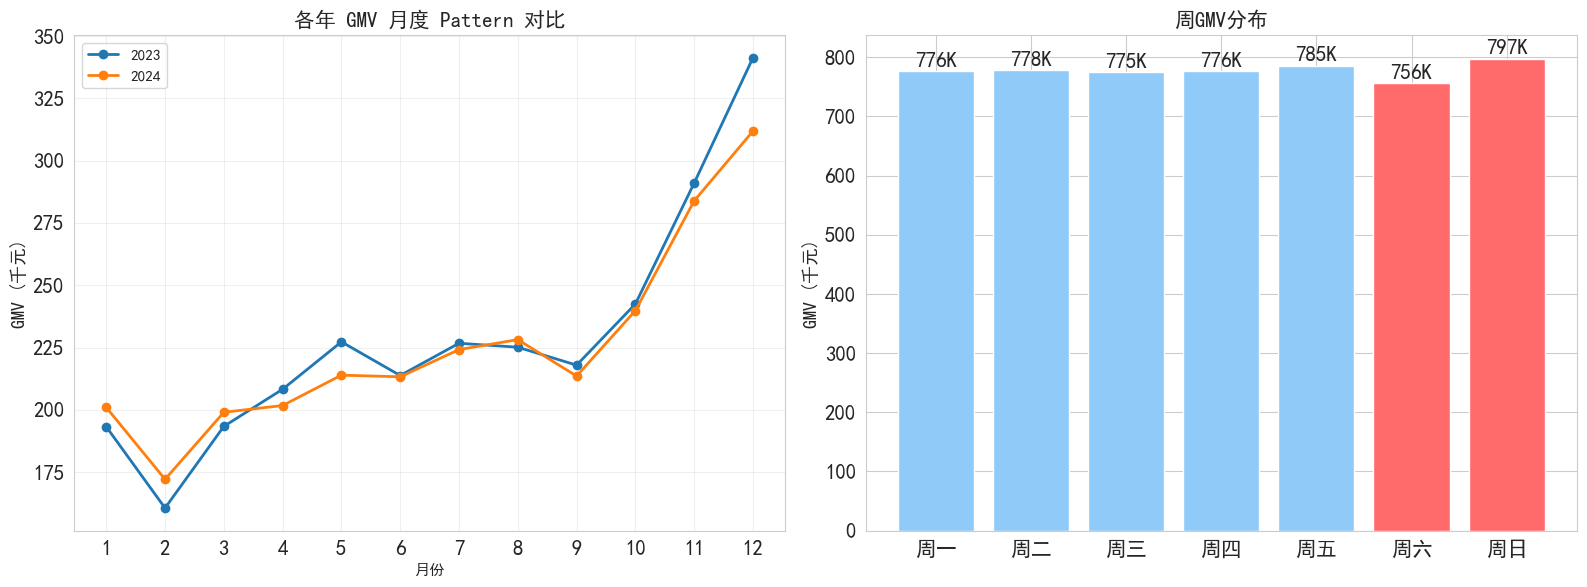

周末订单占比: 28.4%


In [ ]:
# 月度季节性（每年 1-12 月的平均 GMV）
monthly_seasonal = completed.groupby(['year', 'month']).agg(
    gmv=('total_amount', 'sum')
).reset_index()
monthly_seasonal['gmv_k'] = monthly_seasonal['gmv'] / 1000

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 按年对比月度
years = sorted(monthly_seasonal['year'].unique())
for year in years:
    data = monthly_seasonal[monthly_seasonal['year'] == year]
    axes[0].plot(data['month'], data['gmv_k'], marker='o', linewidth=2, label=str(year))
axes[0].tick_params(labelsize=15)
axes[0].set_title('各年GMV月度对比', fontsize=15,fontweight='bold')
axes[0].set_xlabel('月份')
axes[0].set_ylabel('GMV (千元)',fontsize=13)
axes[0].set_xticks(range(1, 13))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 周内对比
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
chinese_labels = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']
dow_gmv = completed.groupby('day_of_week_name').agg(
    gmv=('total_amount', 'sum'),
    orders=('transaction_id', 'nunique')
).reindex(dow_order)

dow_gmv['gmv_k'] = dow_gmv['gmv'] / 1000
axes[1].bar(chinese_labels,dow_gmv['gmv_k'],
            color=['#FF6B6B' if d in ['周六', '周日'] else '#90CAF9' for d in chinese_labels])
axes[1].tick_params(labelsize=15)
axes[1].set_title('周内GMV分布', fontsize=15,fontweight='bold')
axes[1].set_ylabel('GMV (千元)',fontsize=13)
for i, v in enumerate(dow_gmv['gmv_k']):
     axes[1].text(i, v + dow_gmv['gmv_k'].max()*0.01, f'{v:,.0f}K', ha='center', fontsize=15)

plt.tight_layout()
plt.show()

# 关键数字
weekend_share = dow_gmv.loc[['Saturday', 'Sunday'], 'orders'].sum() / dow_gmv['orders'].sum()
print(f"周末订单占比: {weekend_share:.1%}")

**业务解读：**
- **月度 Pattern**：如果每年同一月份都有相似的高低点，说明是周期性因素（如节假日、季节变化），可以提前备货和排营销
- **周度 Pattern**：周末 vs 工作日的差异，直接影响广告投放策略——如果周末转化更好，预算应该向周末倾斜


## 4. 同比环比分析

环比（MoM）看短期波动，同比（YoY）看长期趋势。两者结合才能判断增长质量。

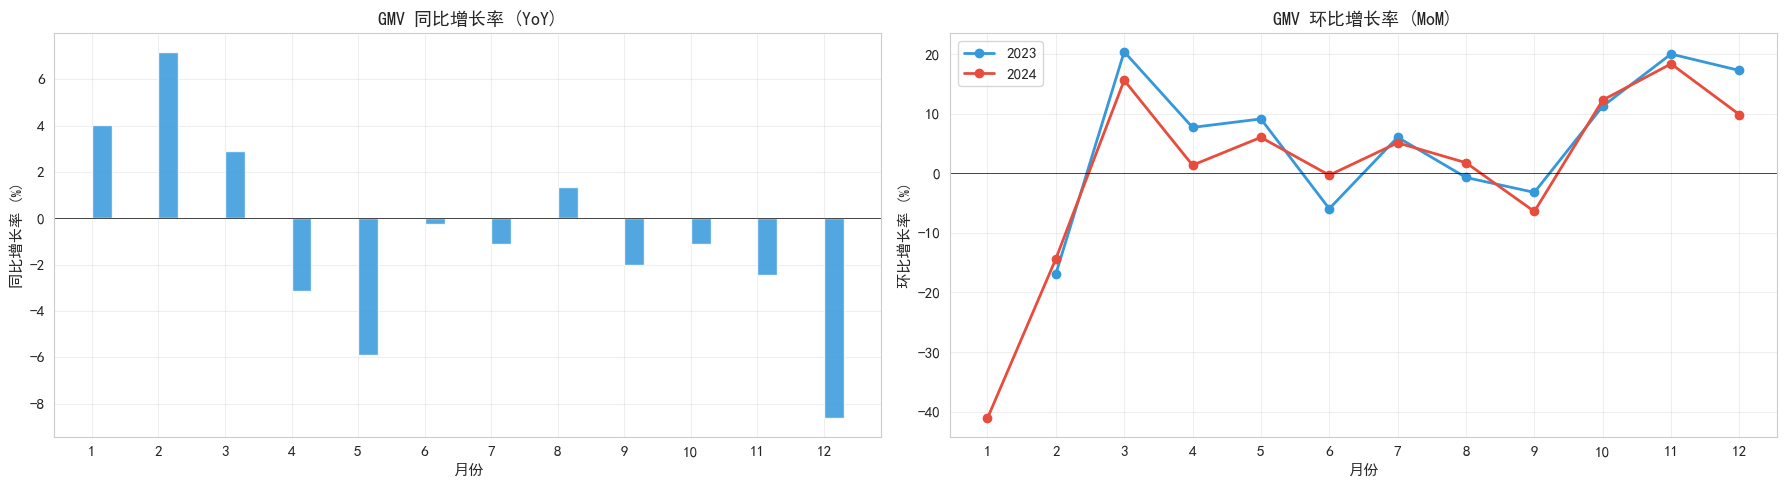

2024 年平均同比增长: -0.8%
月环比标准差: 14.1% 


In [19]:
# 同比分析：对比每年同月的 GMV
yoy = monthly_seasonal.pivot(index='month', columns='year', values='gmv')
yoy.columns = [f'GMV_{col}' for col in yoy.columns]

# 计算同比增长率
if 'GMV_2023' in yoy.columns and 'GMV_2024' in yoy.columns:
    yoy['YoY_2024'] = (yoy['GMV_2024'] - yoy['GMV_2023']) / yoy['GMV_2023'] * 100
if 'GMV_2024' in yoy.columns and 'GMV_2025' in yoy.columns:
    yoy['YoY_2025'] = (yoy['GMV_2025'] - yoy['GMV_2024']) / yoy['GMV_2024'] * 100

# 计算环比（从 monthly_gmv 取，月对月变化）
monthly_gmv['mom_pct'] = monthly_gmv['gmv'].pct_change() * 100
monthly_gmv['year'] = monthly_gmv['year_month'].str[:4].astype(int)
monthly_gmv['month_num'] = monthly_gmv['year_month'].str[5:7].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ===== 左图：同比增长率（柱状图）=====
months = list(range(1, 13))
yoy_cols = [c for c in yoy.columns if c.startswith('YoY')]
colors_yoy = ['#3498db', '#e74c3c']
for idx, col in enumerate(yoy_cols):
    axes[0].bar([m + (0.15 if '2024' in col else -0.15) for m in months],
                yoy[col], width=0.3, alpha=0.85,
                color=colors_yoy[idx % len(colors_yoy)],
                label=col.replace('YoY_', '20'))
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_title('GMV 同比增长率 (YoY)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('月份')
axes[0].set_ylabel('同比增长率 (%)')
axes[0].set_xticks(months)
axes[0].grid(True, alpha=0.3)

# ===== 右图：环比增长率（折线图，按年分色）=====
years_list = sorted(monthly_gmv['year'].unique())
colors_mom = ['#3498db', '#e74c3c']
for idx, yr in enumerate(years_list):
    data = monthly_gmv[monthly_gmv['year'] == yr]
    axes[1].plot(data['month_num'], data['mom_pct'], marker='o', linewidth=2,
                 color=colors_mom[idx % len(colors_mom)], label=str(yr))
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_title('GMV 环比增长率 (MoM)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('月份')
axes[1].set_ylabel('环比增长率 (%)')
axes[1].set_xticks(range(1, 13))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for col in yoy_cols:
    avg = yoy[col].mean()
    print(f"20{col[-2:]} 年平均同比增长: {avg:+.1f}%")
print(f"月环比标准差: {monthly_gmv['mom_pct'].std():.1f}% ")


## 5. 支付方式分析

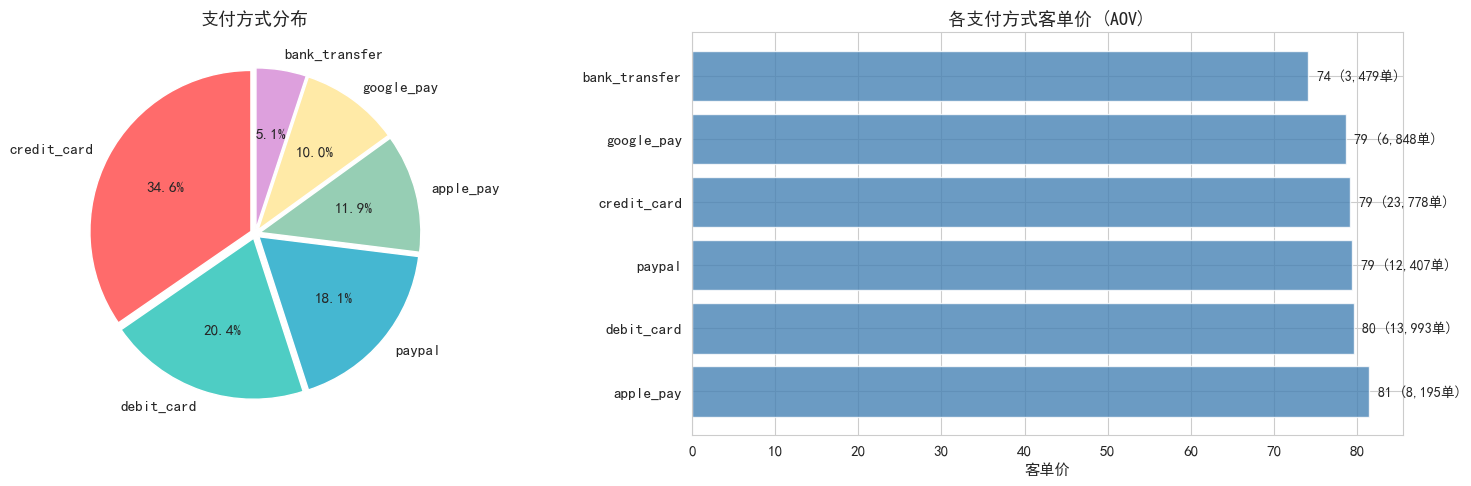

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 支付方式份额
pay_share = completed['payment_method'].value_counts()
colors_pay = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
axes[0].pie(pay_share.values, labels=pay_share.index, autopct='%1.1f%%',
           colors=colors_pay[:len(pay_share)], explode=[0.03]*len(pay_share),
           shadow=False, startangle=90)
axes[0].set_title('支付方式分布', fontsize=13, fontweight='bold')

# 支付方式 × 客单价
pay_aov = completed.groupby('payment_method').agg(
    aov=('total_amount', 'mean'),
    orders=('transaction_id', 'nunique')
).sort_values('aov', ascending=False)

axes[1].barh(pay_aov.index, pay_aov['aov'], color='steelblue', alpha=0.8)
axes[1].set_title('各支付方式客单价 (AOV)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('客单价')
for i, (v, o) in enumerate(zip(pay_aov['aov'], pay_aov['orders'])):
    axes[1].text(v + 1, i, f'{v:.0f} ({o:,}单)', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**业务解读：**
- 不同支付方式的客单价差异，反映了用户群体的不同：信用卡用户可能消费力更高，钱包类支付可能偏年轻用户
- 如果某支付方式份额快速增长，可以从侧面反映客群结构的变化


## 6. 市场分布分析

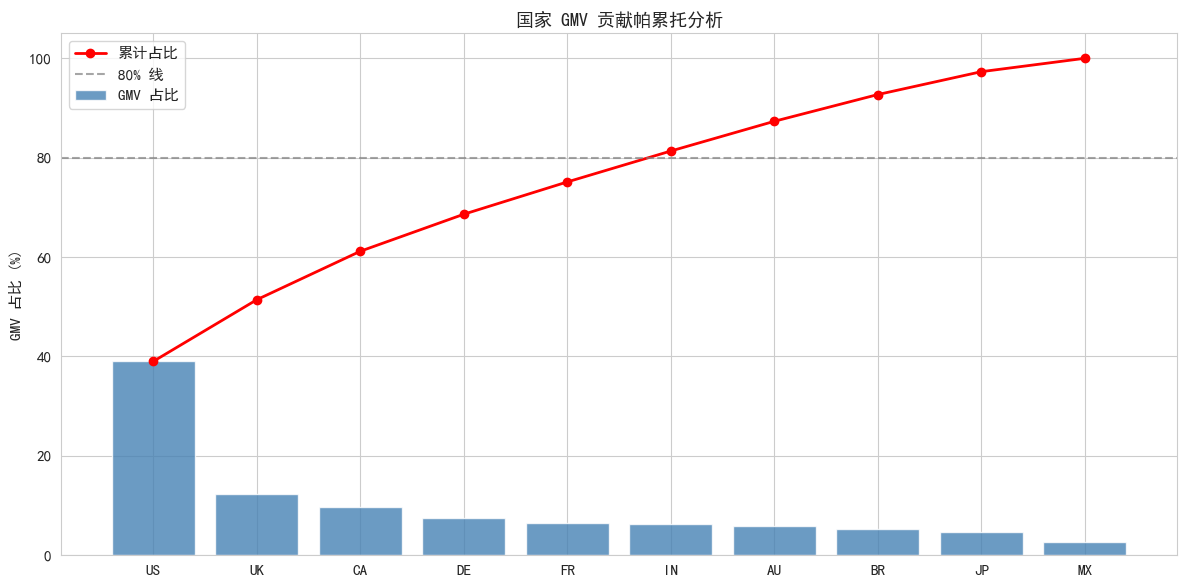

=== 国家维度概览 ===
                gmv  orders  customers        aov  gmv_share  gmv_share_cum
country                                                                    
US       2124285.38   26889       3823  79.002022  39.026062      39.026062
UK        675408.99    8159       1153  82.780854  12.408198      51.434260
CA        530586.73    6867        998  77.266161   9.747613      61.181873
DE        405334.32    5184        738  78.189491   7.446552      68.628425
FR        353837.58    4466        605  79.229194   6.500486      75.128911
IN        338440.70    4234        584  79.934034   6.217624      81.346536
AU        325555.66    4192        605  77.661178   5.980908      87.327444
BR        292870.56    3742        518  78.265783   5.380438      92.707881
JP        250346.70    3103        426  80.678924   4.599215      97.307096
MX        146581.42    1864        280  78.638101   2.692904     100.000000

Top 3 国家贡献 61.2% 的 GMV


In [20]:
# 按国家汇总
country_stats = completed.groupby('country').agg(
    gmv=('total_amount', 'sum'),
    orders=('transaction_id', 'nunique'),
    customers=('customer_id', 'nunique'),
    aov=('total_amount', 'mean')
).sort_values('gmv', ascending=False)
country_stats['gmv_share'] = country_stats['gmv'] / country_stats['gmv'].sum() * 100
country_stats['gmv_share_cum'] = country_stats['gmv_share'].cumsum()

fig, ax = plt.subplots(figsize=(12, 6))

# 帕累托图：GMV 集中度
ax.bar(country_stats.index, country_stats['gmv_share'], color='steelblue', alpha=0.8, label='GMV 占比')
ax.plot(country_stats.index, country_stats['gmv_share_cum'], 'ro-', linewidth=2, markersize=6, label='累计占比')
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.7, label='80% 线')
ax.set_title('国家 GMV 贡献帕累托分析', fontsize=13, fontweight='bold')
ax.set_ylabel('GMV 占比 (%)')
ax.legend()
ax.tick_params(axis='x')

plt.tight_layout()
plt.show()

print("=== 国家维度概览 ===")
print(country_stats.to_string())
print(f"\nTop 3 国家贡献 {country_stats['gmv_share'].iloc[:3].sum():.1f}% 的 GMV")

**业务解读：**
- 帕累托图直接体现了市场集中度。Top 3 国家是否贡献了 80%+ 的 GMV？如果是，说明业务依赖少数市场，需要考虑分散风险
- 国家差异可能反映购买力差异，也可能反映品类偏好差异——需要结合商品分析来验证


## 7. 折扣效果分析

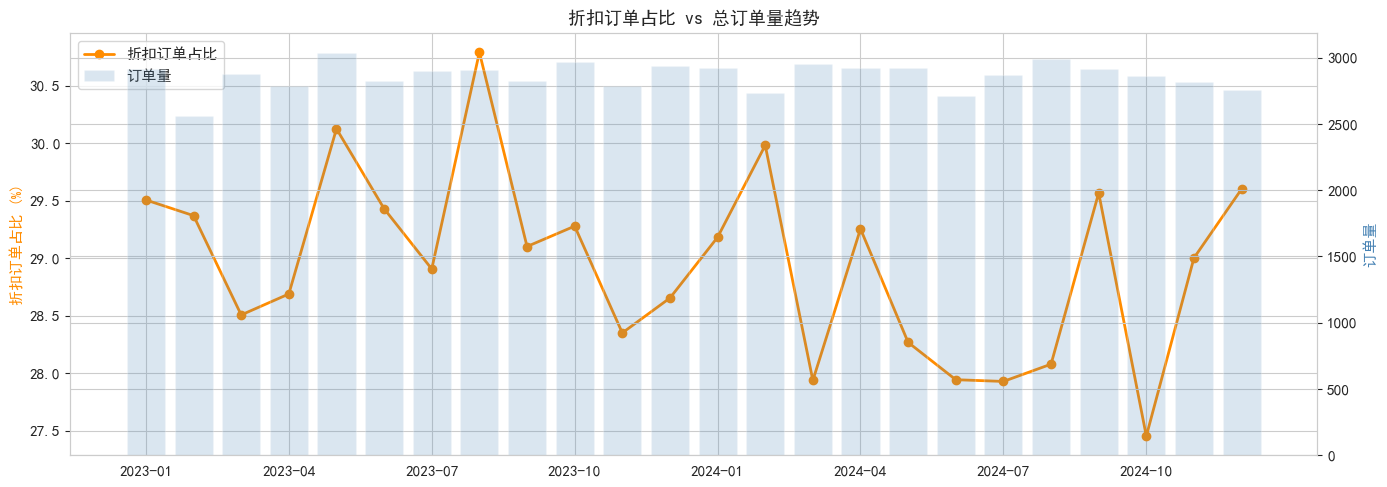


折扣订单 AOV: 65.28
非折扣订单 AOV: 84.92
AOV 差异: -19.63


In [ ]:
# 折扣 vs 非折扣订单
completed['has_discount'] = (completed['discount_applied'] > 0).astype(int)

discount_stats = completed.groupby('has_discount').agg(
    orders=('transaction_id', 'nunique'),
    aov=('total_amount', 'mean'),
    total_gmv=('total_amount', 'sum')
)
discount_stats['order_share'] = discount_stats['orders'] / discount_stats['orders'].sum() * 100

# 折扣率 vs 订单量（按月）
monthly_discount = completed.groupby('year_month').agg(
    discount_order_pct=('has_discount', 'mean'),
    orders=('transaction_id', 'nunique'),
    aov=('total_amount', 'mean')
).reset_index()
monthly_discount['year_month'] = monthly_discount['year_month'].astype(str)
monthly_discount['discount_order_pct'] = monthly_discount['discount_order_pct'] * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_discount['discount_order_pct'], marker='o', color='darkorange', linewidth=2, label='折扣订单占比')
ax.set_ylabel('折扣订单占比 (%)', color='darkorange')
ax.set_xticks(range(0, len(monthly_discount), 3))
ax.set_xticklabels(monthly_discount['year_month'].iloc[::3])

ax2 = ax.twinx()
ax2.bar(range(len(monthly_discount)), monthly_discount['orders'], alpha=0.2, color='steelblue', label='订单量')
ax2.set_ylabel('订单量', color='steelblue')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax.set_title('折扣订单占比 vs 总订单量趋势', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n折扣订单 AOV: {discount_stats.loc[1, 'aov']:.2f}")
print(f"非折扣订单 AOV: {discount_stats.loc[0, 'aov']:.2f}")
print(f"AOV 差异: {(discount_stats.loc[1, 'aov'] - discount_stats.loc[0, 'aov']):.2f}")

**业务解读：**
- 折扣订单的 AOV 通常低于非折扣订单——这意味着折扣拉动了"买便宜货"的用户，但不一定拉高了总 GMV
- 关键看：**折扣订单占比上升时，总订单量是否同步上升？** 如果折扣越多但总订单不变，说明折扣只是在"补贴本来就会买的用户"


---

## 8.小结

| 分析维度 | 关键发现 | 业务建议 |
|----------|---------|---------|
| GMV趋势 | 见GMV趋势 | 关注增长驱动因素 |
| 月度与周内 | 见月度和周内表| 旺季提前备货，淡季加大促销 |
| 同环比增长 | 见YoY和MoM表 | 如果同比下滑，排查竞品和市场变化 |
| 支付方式 | 见支付分布 | 优化高 AOV 支付渠道的体验 |
| 国家集中度 | 帕累托分析 | Top市场做深，新兴市场做宽 |
| 折扣效果 | 折扣 vs 非折扣 | 控制折扣预算，避免补贴已有用户 |

**核心逻辑：** 销售分析的每一步都是"先看总量 → 拆维度 → 找异常 → 形成假设 → 用数据验证"。这四个步骤贯穿所有分析模块。
